In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def cargar_imagen(ruta_imagen):
    imagen = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)  # Cargar en escala de grises
    if imagen is None:
        raise ValueError("La imagen no se pudo cargar correctamente.")
    return imagen

In [3]:
def normalizar_imagen(imagen):
    return cv2.normalize(imagen, None, 0, 255, cv2.NORM_MINMAX)

In [4]:
def filtro_gaussiano(imagen, tamaño_kernel=5):
    return cv2.GaussianBlur(imagen, (tamaño_kernel, tamaño_kernel), 0)

In [5]:
def filtro_sobel(imagen):
    sobel_x = cv2.Sobel(imagen, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(imagen, cv2.CV_64F, 0, 1, ksize=3)
    sobel_magnitud = cv2.magnitude(sobel_x, sobel_y)
    return np.uint8(sobel_magnitud)

In [6]:
def erosion(imagen, tamaño_kernel=(3, 3)):
    kernel = np.ones(tamaño_kernel, np.uint8)
    return cv2.erode(imagen, kernel, iterations=1)

In [7]:
def dilatacion(imagen, tamaño_kernel=(3, 3)):
    kernel = np.ones(tamaño_kernel, np.uint8)
    return cv2.dilate(imagen, kernel, iterations=1)

In [8]:
def apertura(imagen, tamaño_kernel=(3, 3)):
    kernel = np.ones(tamaño_kernel, np.uint8)
    return cv2.morphologyEx(imagen, cv2.MORPH_OPEN, kernel)

In [9]:
def clausura(imagen, tamaño_kernel=(3, 3)):
    kernel = np.ones(tamaño_kernel, np.uint8)
    return cv2.morphologyEx(imagen, cv2.MORPH_CLOSE, kernel)

In [10]:
def mostrar_resultados(imagen_original, imagen_gaussiana, imagen_sobel, imagen_erosion, imagen_dilatacion, imagen_apertura, imagen_clausura):
    plt.figure(figsize=(15, 12))

    plt.subplot(3, 3, 1)
    plt.title("Imagen Original")
    plt.imshow(imagen_original, cmap='gray')
    plt.axis('off')

    plt.subplot(3, 3, 2)
    plt.title("Filtro Gaussiano")
    plt.imshow(imagen_gaussiana, cmap='gray')
    plt.axis('off')

    plt.subplot(3, 3, 3)
    plt.title("Filtro Sobel")
    plt.imshow(imagen_sobel, cmap='gray')
    plt.axis('off')

    plt.subplot(3, 3, 4)
    plt.title("Erosión")
    plt.imshow(imagen_erosion, cmap='gray')
    plt.axis('off')

    plt.subplot(3, 3, 5)
    plt.title("Dilatación")
    plt.imshow(imagen_dilatacion, cmap='gray')
    plt.axis('off')

    plt.subplot(3, 3, 6)
    plt.title("Apertura")
    plt.imshow(imagen_apertura, cmap='gray')
    plt.axis('off')

    plt.subplot(3, 3, 7)
    plt.title("Clausura")
    plt.imshow(imagen_clausura, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

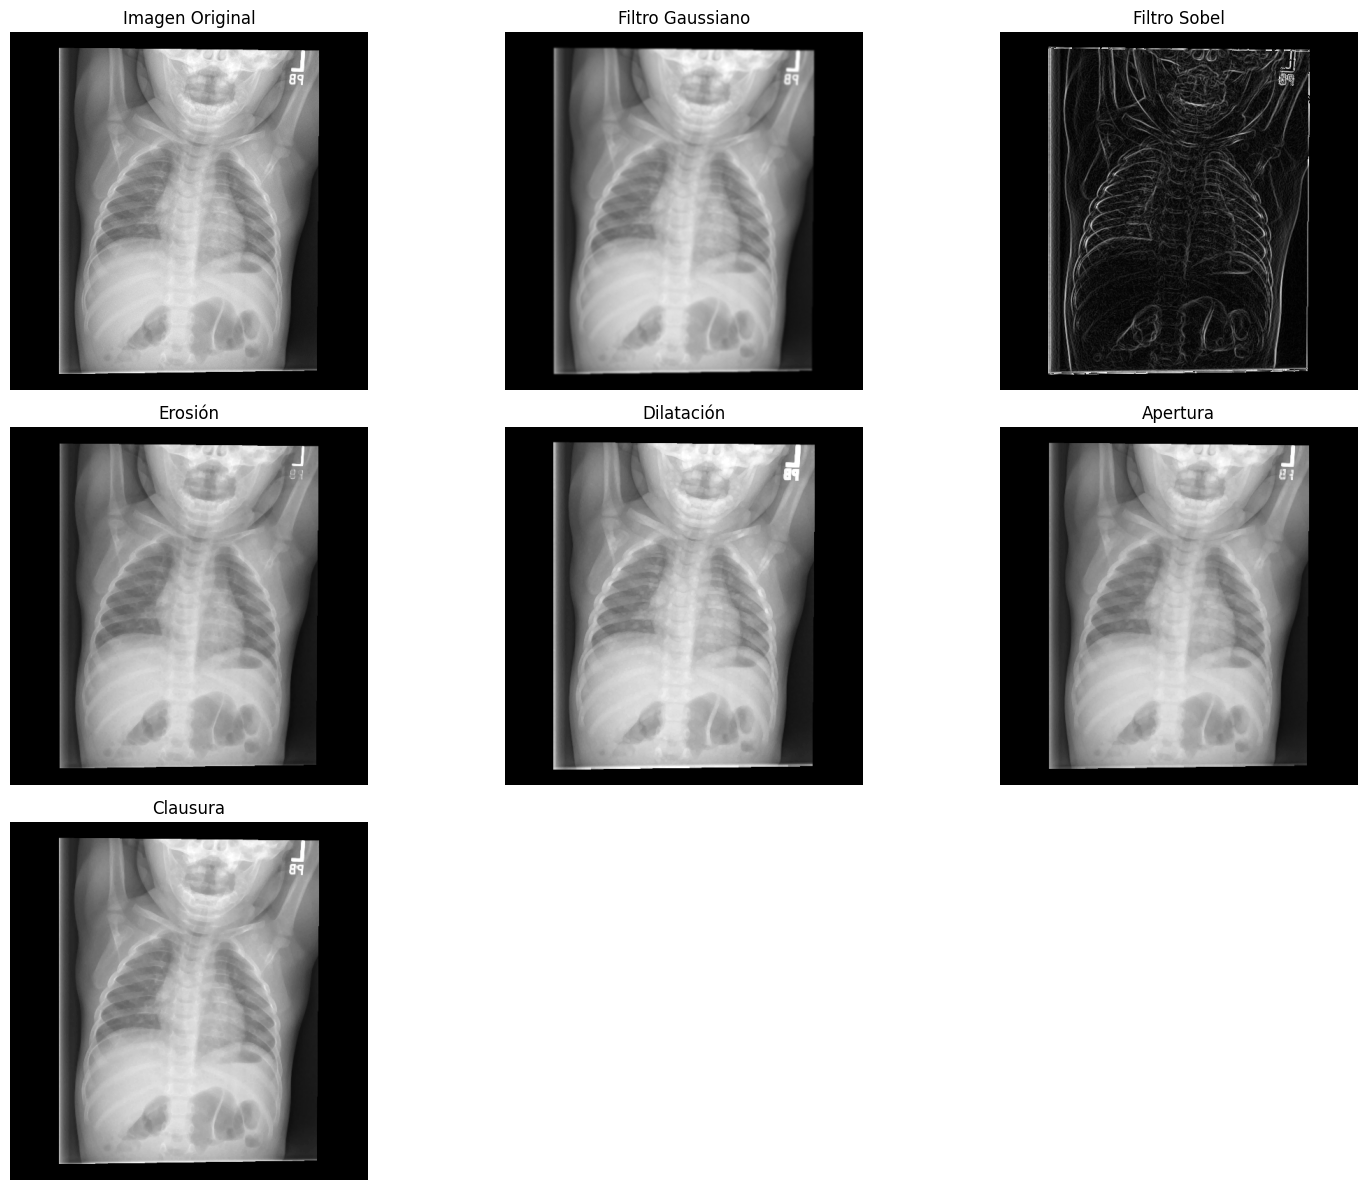

In [11]:
ruta_img_front = '../../data/img/imagenMedicaFrontal.jpg'
ruta_img_lat = '../../data/img/imagenMedicaLateral.jpg'

 
img_front = cargar_imagen(ruta_img_front)

img_normalizada = normalizar_imagen(img_front)

img_gaussiana = filtro_gaussiano(img_normalizada, tamaño_kernel=5)
img_sobel = filtro_sobel(img_normalizada)

img_erosion = erosion(img_normalizada)
img_dilatacion = dilatacion(img_normalizada)
img_apertura = apertura(img_normalizada)
img_clausura = clausura(img_normalizada)

mostrar_resultados(img_front, img_gaussiana, img_sobel, img_erosion, img_dilatacion, img_apertura, img_clausura)

In [ ]:
# 1. Cargar la imagen en escala de grises
image = cv2.imread(ruta_img_front, cv2.IMREAD_GRAYSCALE)

# 2. Normalizar la imagen a escala de 0 a 255 (si es necesario)
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)

# 3. Ecualización del histograma para mejorar el contraste
image_eq = cv2.equalizeHist(image)

# 4. Aplicar un filtro Gaussiano para reducción de ruido
gaussian_blur = cv2.GaussianBlur(image_eq, (5, 5), 0)

# 5. Detección de bordes utilizando el filtro de Sobel
sobel_x = cv2.Sobel(gaussian_blur, cv2.CV_64F, 1, 0, ksize=3)  # Gradiente en dirección X
sobel_y = cv2.Sobel(gaussian_blur, cv2.CV_64F, 0, 1, ksize=3)  # Gradiente en dirección Y

# 6. Calcular la magnitud del gradiente de Sobel
magnitude = cv2.magnitude(sobel_x, sobel_y)
magnitude = np.uint8(np.clip(magnitude, 0, 255))  # Escalar a 0-255

# 7. Aplicar operaciones morfológicas para mejorar la imagen
kernel = np.ones((5, 5), np.uint8)  # Definir el tamaño del kernel para morfología

# Erosión: elimina pequeños detalles y ruido
erosion = cv2.erode(magnitude, kernel, iterations=1)

# Dilatación: resalta los bordes y aumenta las áreas de interés
dilation = cv2.dilate(magnitude, kernel, iterations=1)

# 8. Resaltar los bordes combinados con la imagen original
result_image = cv2.addWeighted(image, 0.7, magnitude, 0.3, 0)

# 9. Mostrar los resultados
plt.figure(figsize=(15, 10))

# Imagen original
plt.subplot(2, 3, 1)
plt.title("Imagen Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

# Imagen ecualizada
plt.subplot(2, 3, 2)
plt.title("Imagen Ecualizada")
plt.imshow(image_eq, cmap='gray')
plt.axis('off')

# Imagen con filtro Gaussiano
plt.subplot(2, 3, 3)
plt.title("Filtro Gaussiano")
plt.imshow(gaussian_blur, cmap='gray')
plt.axis('off')

# Magnitud del gradiente (bordes detectados)
plt.subplot(2, 3, 4)
plt.title("Bordes - Sobel")
plt.imshow(magnitude, cmap='gray')
plt.axis('off')

# Imagen con erosión
plt.subplot(2, 3, 5)
plt.title("Erosión")
plt.imshow(erosion, cmap='gray')
plt.axis('off')

# Imagen con dilatación
plt.subplot(2, 3, 6)
plt.title("Dilatación")
plt.imshow(dilation, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()
